## Desarrollo tarea HW Sesión 4

Felipe López Vergara

## 1. Simulación

Suponga un proceso $\epsilon_t$ con media cero y varianza igual a 3. Se sabe que, $\mathbb{E}(y_t) = 10$ y condición inicial es $y_1 = 9$ y $y_2 = 10.3$. Simule, recursivamente, 100 periodos para la variable $y_t$ para los siguientes modelos.

In [31]:
from matplotlib import pyplot as plt 
from scipy.stats import lognorm
import statsmodels.api as sm
import pandas as pd 
import seaborn as sns
import yfinance as yf
import numpy as np


sns.set_style("dark")

*AR(1) con $\phi_1 = 0,4$, $\phi_1 = 0,8$ y $\phi_1 = 0,99$

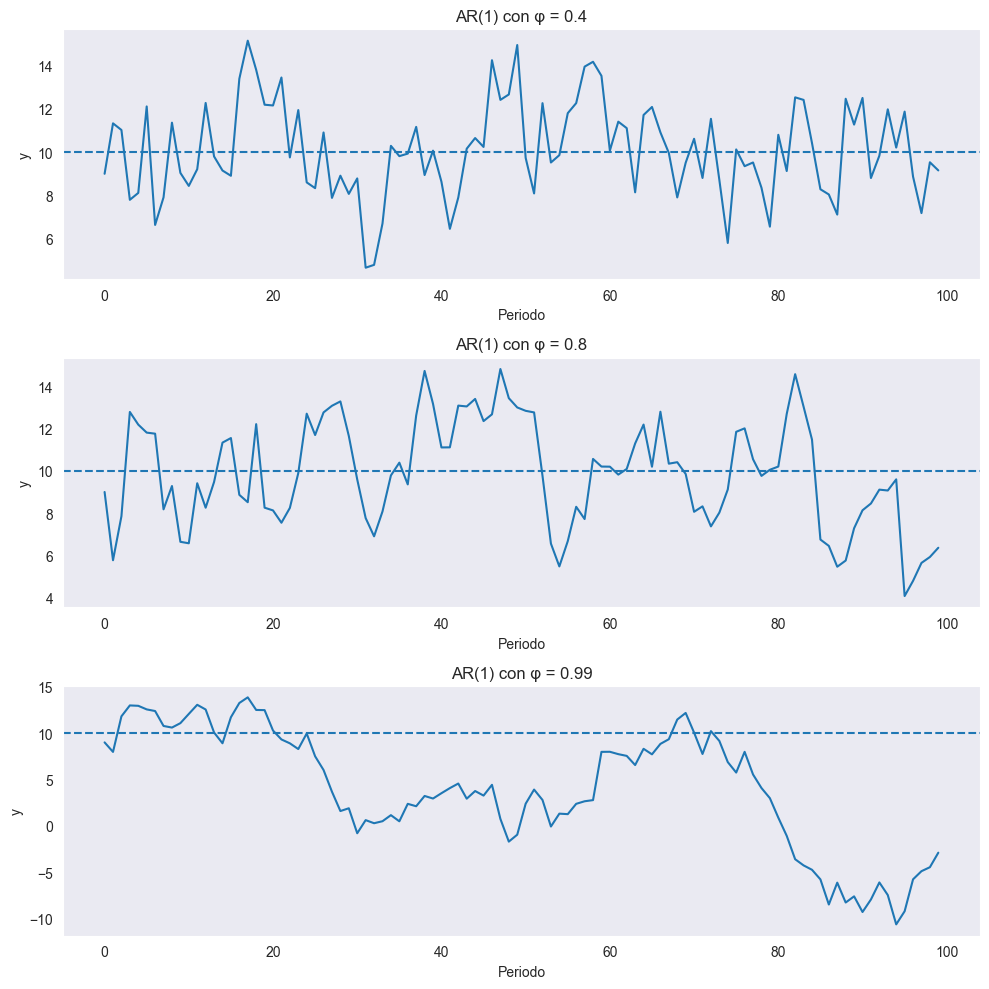

In [2]:
from statsmodels.tsa.arima_process import ArmaProcess

# Fijar semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
sigma = np.sqrt(3)

# Valores de phi
phis = [0.4, 0.8, 0.99]

# Crear una figura
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

for i, phi in enumerate(phis):

    # Generar errores
    e = np.random.normal(0, sigma, T)

    # Inicializar la serie
    y = np.zeros(T)
    y[0] = 9

    # Simulación recursiva
    for t in range(1, T):
        y[t] = mu + phi*(y[t-1] - mu) + e[t]

    # Graficar
    ax[i].plot(y)
    ax[i].axhline(mu, linestyle='--')
    ax[i].set_title(f'AR(1) con φ = {phi}')
    ax[i].set_xlabel('Periodo')
    ax[i].set_ylabel('y')

plt.tight_layout()
plt.show()

*AR(2) con $\phi_1 = 0,2$, $\phi_1 = 0,4$ y $\phi_1 = 0,8$ y $\phi_2 = -0,05$

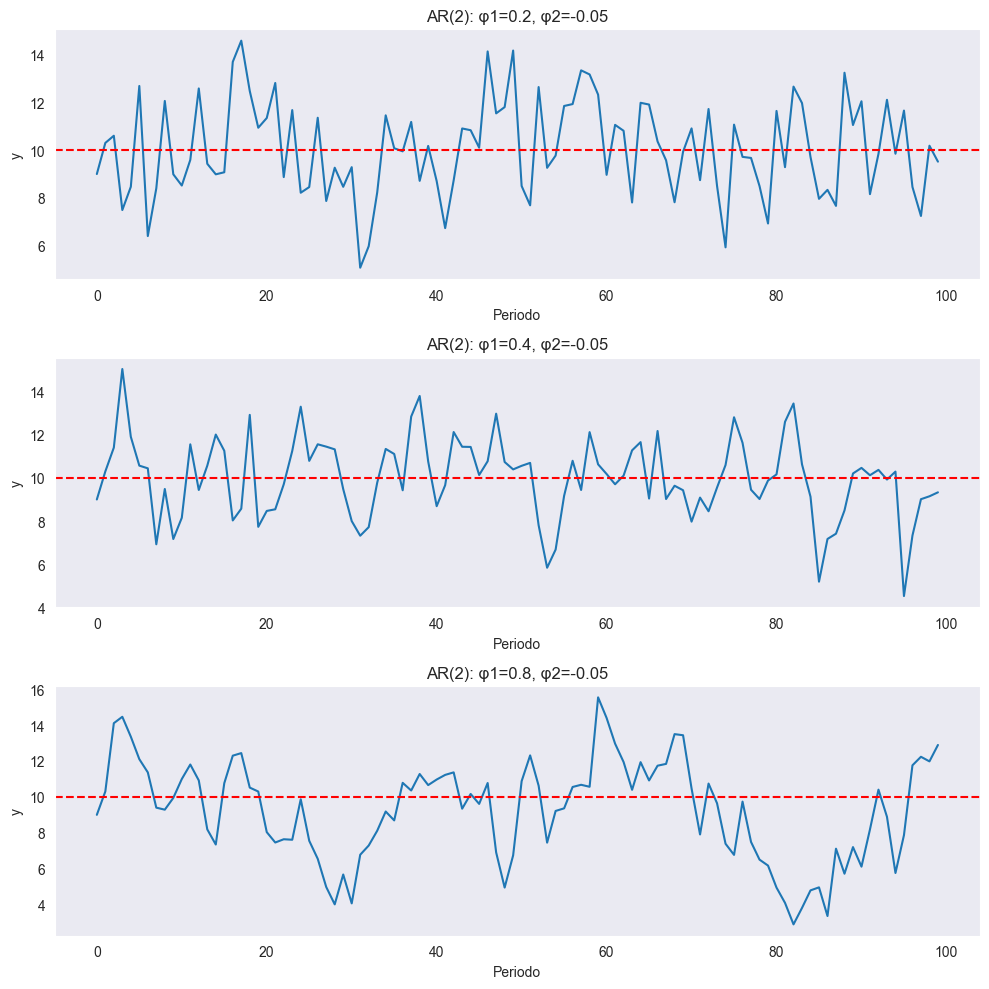

In [3]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
sigma = np.sqrt(3)

# Valores de phi1
phi1_vals = [0.2, 0.4, 0.8]
phi2 = -0.05

# DataFrame para guardar las simulaciones
simulaciones = pd.DataFrame(index=range(1, T+1))

# Crear gráficos
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

for i, phi1 in enumerate(phi1_vals):

    # Generar errores
    e = np.random.normal(0, sigma, T)

    # Inicializar la serie
    y = np.zeros(T)
    y[0] = 9
    y[1] = 10.3

    # Simulación recursiva
    for t in range(2, T):
        y[t] = (mu
                + phi1*(y[t-1] - mu)
                + phi2*(y[t-2] - mu)
                + e[t])

    # Guardar resultados
    simulaciones[f'AR2_phi1_{phi1}'] = y

    # Graficar
    ax[i].plot(y)
    ax[i].axhline(mu, color='red', linestyle='--')
    ax[i].set_title(f'AR(2): φ1={phi1}, φ2={phi2}')
    ax[i].set_xlabel('Periodo')
    ax[i].set_ylabel('y')

plt.tight_layout()
plt.show()

*MA(1) con $\theta_1 = 0.5$ y $\theta_1 = 2$

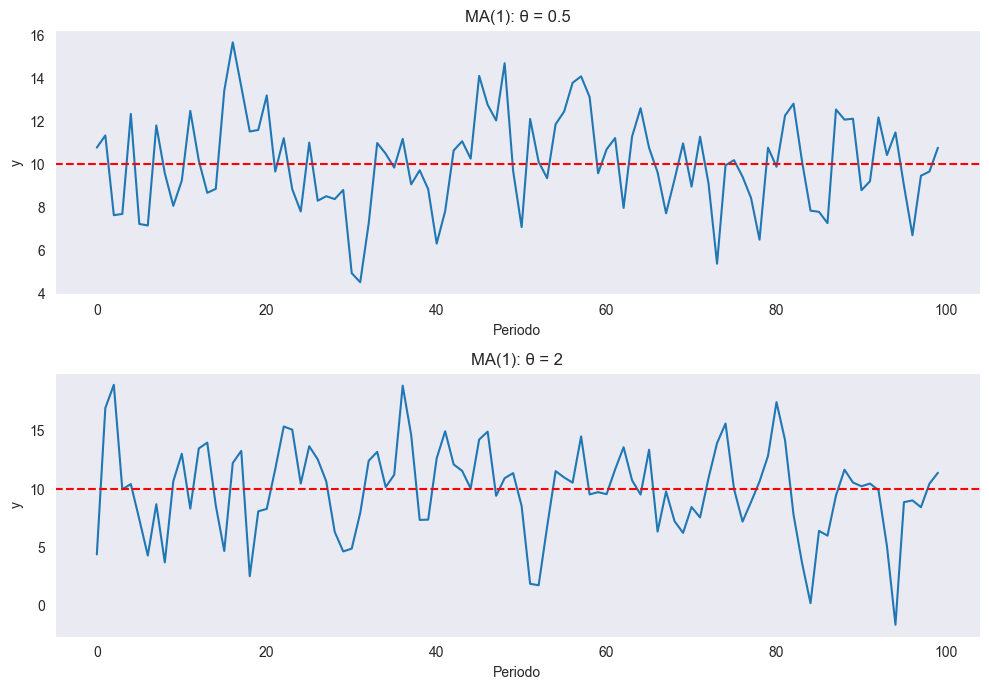

In [4]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
sigma = np.sqrt(3)

# Valores de theta
thetas = [0.5, 2]

# DataFrame para guardar simulaciones
simulaciones = pd.DataFrame(index=range(1, T+1))

# Generar gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

for i, theta in enumerate(thetas):

    # Generar errores
    e = np.random.normal(0, sigma, T + 1)

    # Inicializar serie
    y = np.zeros(T)

    # Simulación recursiva
    for t in range(T):
        y[t] = mu + e[t+1] + theta * e[t]

    # Guardar resultados
    simulaciones[f'MA1_theta_{theta}'] = y

    # Graficar
    ax[i].plot(y)
    ax[i].axhline(mu, color='red', linestyle='--')
    ax[i].set_title(f'MA(1): θ = {theta}')
    ax[i].set_xlabel('Periodo')
    ax[i].set_ylabel('y')

plt.tight_layout()
plt.show()

*ARMA(1,1) con $\phi_1 = 0,4$ y $\theta_1 = 0,5$

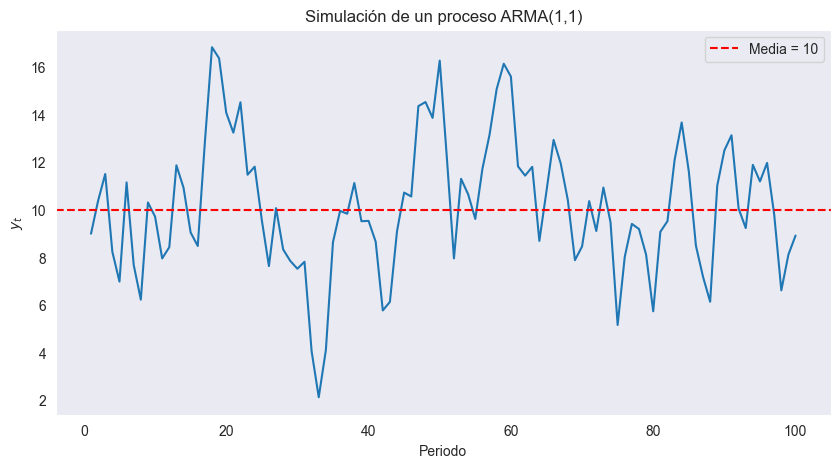

In [5]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
phi = 0.4
theta = 0.5
sigma = np.sqrt(3)

# Generar errores
e = np.random.normal(0, sigma, T + 1)

# Inicializar la serie
y = np.zeros(T)
y[0] = 9

# Simulación recursiva
for t in range(1, T):
    y[t] = (mu
            + phi*(y[t-1] - mu)
            + e[t]
            + theta*e[t-1])

# Guardar en DataFrame
df = pd.DataFrame({
    'Periodo': np.arange(1, T+1),
    'ARMA(1,1)': y
})

# Graficar
plt.figure(figsize=(10,5))
plt.plot(df['Periodo'], df['ARMA(1,1)'])
plt.axhline(mu, color='red', linestyle='--', label='Media = 10')
plt.xlabel('Periodo')
plt.ylabel('$y_t$')
plt.title('Simulación de un proceso ARMA(1,1)')
plt.legend()
plt.show()

ARMA 2.1

## 3. Series Macroeconomicas

Obtener la serie de IMACEC (frecuencia mensual entre 2010 enero y 2024 diciembre) de la página del Banco Central de Chile (mediante API REST), si es necesario hacer los empalmes para contar con una serie larga.


In [13]:
import bcchapi
from config import * # contiene user y pass

conn = bcchapi.Siete(USER, PASS)

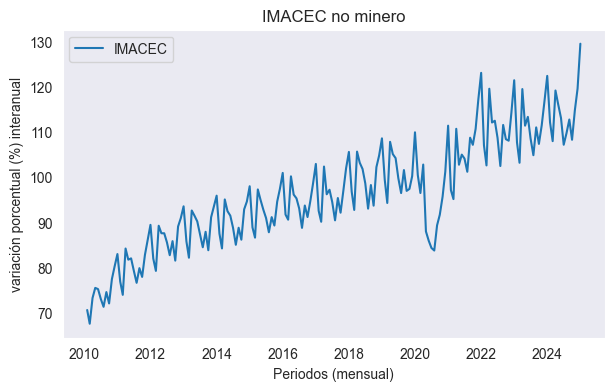

In [17]:
imacec_df = conn.cuadro(
    series = ['F032.IMC.IND.Z.Z.EP18.N03.Z.0.M'], # codigo relacionado al IMACEC no minero
    nombres = ["IMACEC"],
    desde = "2010-01-01",
    hasta = "2024-12-01",
    frecuencia = "ME",
    observado = "mean")

# Plot series de IMACEC no minero

plt.figure(figsize=(7,4))
sns.lineplot(data = imacec_df)
plt.xlabel('Periodos (mensual)')
plt.ylabel('variación porcentual (%) interanual')
plt.title('IMACEC no minero')
plt.show()

In [22]:
# Funcion que chequea si la serie es estacionaria
from statsmodels.tsa.stattools import adfuller

def valida_estacionariedad(serie, nivel_significancia = 0.05):

  # Aplica Test
  df_series = adfuller(serie)

  # Extrae Resultados
  estadistico_adf = df_series[0] # Estadistico del Test
  p_value = df_series[1]         # P-Valor
  lags_num = df_series[2]        # Rezagos
  o_obs = df_series[3]           # Num. Observaciones
  val_criticos = df_series[4]    # Valores Criticos

  # Determina si la serie es estacionaria
  es_estacionaria = p_value < nivel_significancia

  # Genera resumen de resultados
  resultado = {
      'Estadistico ADF': estadistico_adf,
      'P-Valor': p_value,
      'Rezagos': lags_num,
      'Num. Observaciones': o_obs,
      'valores criticos': val_criticos,
      'Es Estacionaria': es_estacionaria
  }

  # Muestra resultados
  print(f"Estadistico ADF: {estadistico_adf}")
  print(f"P-Valor: {p_value}")
  print(f"Numero de lags utilizados: {lags_num}")
  print(f"Numero de  Observaciones: {o_obs}")
  print(f"Valores Criticos: {val_criticos}")
  for clave, valor in val_criticos.items():
    print(f"  {clave}: {valor}")
  if es_estacionaria:
        print(f"La serie es estacionaria: {es_estacionaria}")
  else:
        print(f"La serie no es estacionaria: {es_estacionaria}")

  return resultado

valida_estacionariedad(imacec_df)

Estadistico ADF: -0.8353403087446362
P-Valor: 0.8085201166771672
Numero de lags utilizados: 13
Numero de  Observaciones: 166
Valores Criticos: {'1%': np.float64(-3.4703698981001665), '5%': np.float64(-2.8791138497902193), '10%': np.float64(-2.576139407751488)}
  1%: -3.4703698981001665
  5%: -2.8791138497902193
  10%: -2.576139407751488
La serie no es estacionaria: False


{'Estadistico ADF': np.float64(-0.8353403087446362),
 'P-Valor': np.float64(0.8085201166771672),
 'Rezagos': 13,
 'Num. Observaciones': 166,
 'valores criticos': {'1%': np.float64(-3.4703698981001665),
  '5%': np.float64(-2.8791138497902193),
  '10%': np.float64(-2.576139407751488)},
 'Es Estacionaria': np.False_}

¿Qué puede decir respecto de la estacionariedad del IMACEC?

Se puede decir solo haciendo un análisis visual que es una serie de tiempo no estacionaria, se ve una tendencia al alza que se rompe el el año 2020 por lo efectos de la pandemia. Además bajo el análisis del test Dickey Fuller (ADF) la hipótesis nula es que la serie no es estacionaria, como muetra un pvalue mayor a 0.05 entonces no se rechaza por lo tanto es no estacionaria.

Presente las funciones de autocorrelación (con 24 rezagos) del IMACEC y de su primera diferencia. ¿Qué le sugieren estos resultados?. Justificar con cálculos del estadístico Ljung-Box.

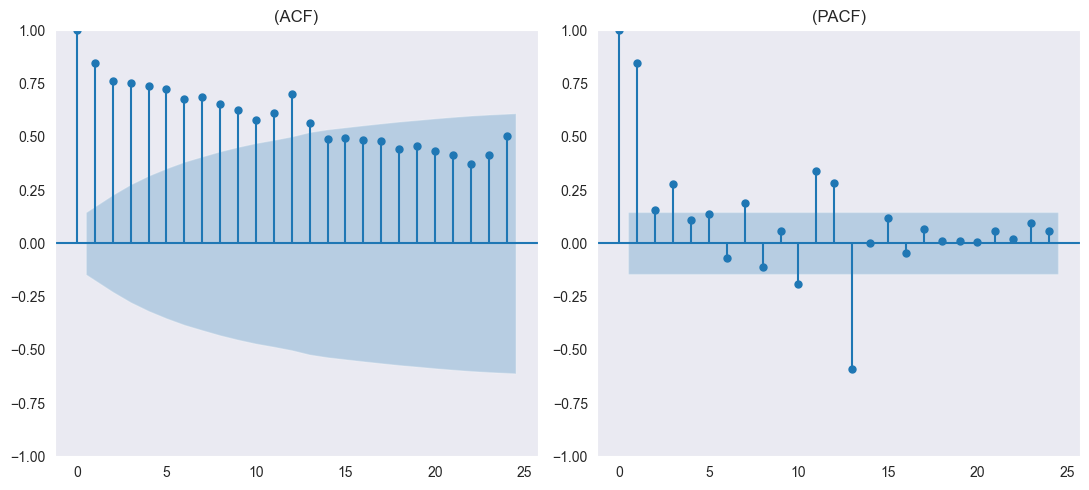

In [ ]:
# Funcion que genera ACF y PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(serie, lags = None):

  # Configuro la figura a mostrar como subplots
  fig, axes = plt.subplots(1, 2, figsize=(11,5))

  # Grafico ACF
  plot_acf(serie, lags = lags, ax = axes[0], title = '(ACF)', zero = True)

  # Grafico PACF
  plot_pacf(serie, lags = lags, ax = axes[1], title = '(PACF)', zero = True)

  # Visualiza
  plt.tight_layout()
  plt.show()

# ACF y PACF Serie Imacec
plot_acf_pacf(imacec_df, lags = 24)

Las barras (autocorrelaciones) comienzan muy altas (cercanas a 1.0) y van bajando de forma muy gradual y lineal a medida que aumentan los rezagos, también casi todas se salen de la banda de confianza sombreada en azul. Por lo que los valores pasados siguen estando fuertemente correlacionados con el valor actual incluso muchos meses después.

Aplique el enfoque Box-Jenkins

In [35]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Rango de órdenes a probar
p_values = range(0, 4)  # AR
q_values = range(0, 4)  # MA

# Guardar resultados
resultados = []

for p in p_values:
    for q in q_values:
        if p == 0 and q == 0:
            continue  
        try:
            modelo = ARIMA(imacec_df, order = (p, 0, q), enforce_stationarity = False,
                           enforce_invertibility = False)
            resultado = modelo.fit()
            aic = resultado.aic
            bic = resultado.bic
            hqic = resultado.hqic
            
            resultados.append({
                'p': p,
                'q': q,
                'AIC': aic,
                'BIC': bic,
                'HQIC': hqic
            })
        except:
            continue  

resultados_df = pd.DataFrame(resultados).sort_values(by = 'AIC').reset_index(drop = True)
print(resultados_df.sort_values('BIC'))
warnings.simplefilter('ignore', ConvergenceWarning)

    p  q          AIC          BIC         HQIC
0   3  3  1058.993210  1084.357082  1069.280671
1   2  3  1077.845449  1100.038836  1086.846977
2   1  3  1081.060388  1100.083292  1088.775983
3   2  2  1081.347310  1100.404209  1089.076048
4   3  2  1083.250480  1105.483528  1092.267341
5   1  2  1091.867602  1107.748351  1098.308217
6   3  1  1096.497461  1115.554360  1104.226199
7   2  1  1105.375854  1121.284772  1111.827347
8   3  0  1107.449740  1123.330489  1113.890355
9   1  1  1113.387270  1126.114405  1118.548465
10  2  0  1133.286215  1146.013350  1138.447410
11  1  0  1144.992075  1154.554233  1148.869454
12  0  3  1178.342756  1194.195176  1184.772419
13  0  2  1220.948035  1233.652634  1226.100527
14  0  1  1243.669977  1253.215328  1247.540873


In [43]:
best_order_model = ARIMA(imacec_df, order = (2, 0, 3))
best_model_fit = best_order_model.fit()
best_model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 IMACEC   No. Observations:                  180
Model:                 ARIMA(2, 0, 3)   Log Likelihood                -547.968
Date:                Mon, 29 Jun 2026   AIC                           1109.936
Time:                        00:17:13   BIC                           1132.287
Sample:                    01-31-2010   HQIC                          1118.999
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         96.2652     19.296      4.989      0.000      58.446     134.084
ar.L1          0.5281      0.248      2.133      0.033       0.043       1.013
ar.L2          0.4672      0.249      1.876      0.061      -0.021       0.955
ma.L1          0.1099      0.237      0.463      0.643      -0.355       0.575
ma.L2         -0.6550      0.090     -7.273      0.000      -0.832      -0.479
ma.L3          0.0028      0.143      0.020      0.984      -0.278       0.284
sigma2        25.2711      2.929      8.628      0.000      19.530      31.012
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 1.93
Prob(Q):                              0.73   Prob(JB):                         0.38
Heteroskedasticity (H):               2.38   Skew:                             0.23
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [49]:
# almaceno resiudos del modelo arma(2,3)
residuos = best_model_fit.resid 

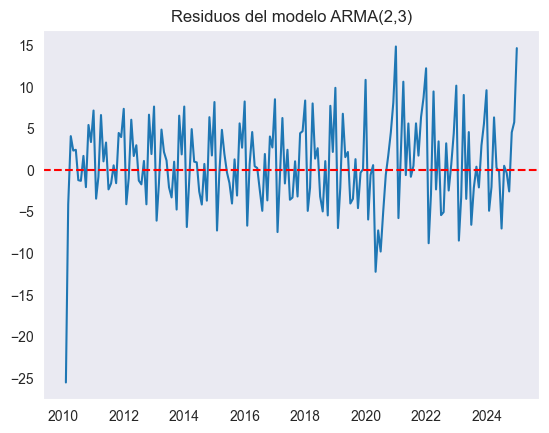

In [50]:
plt.plot(residuos)
plt.title("Residuos del modelo ARMA(2,3)")
plt.axhline(0, color = 'red', linestyle = '--')
plt.show()

In [51]:
valida_estacionariedad(residuos)

Estadistico ADF: -3.957604503731707
P-Valor: 0.0016495218571012057
Numero de lags utilizados: 13
Numero de  Observaciones: 166
Valores Criticos: {'1%': np.float64(-3.4703698981001665), '5%': np.float64(-2.8791138497902193), '10%': np.float64(-2.576139407751488)}
  1%: -3.4703698981001665
  5%: -2.8791138497902193
  10%: -2.576139407751488
La serie es estacionaria: True


{'Estadistico ADF': np.float64(-3.957604503731707),
 'P-Valor': np.float64(0.0016495218571012057),
 'Rezagos': 13,
 'Num. Observaciones': 166,
 'valores criticos': {'1%': np.float64(-3.4703698981001665),
  '5%': np.float64(-2.8791138497902193),
  '10%': np.float64(-2.576139407751488)},
 'Es Estacionaria': np.True_}

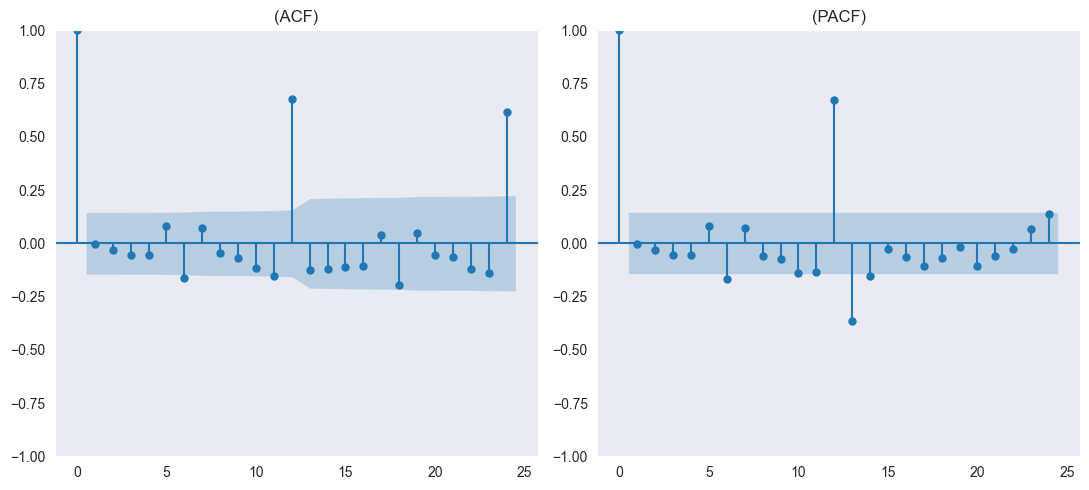

In [52]:
plot_acf_pacf(residuos, lags = 24)

In [53]:
from statsmodels.stats.diagnostic import acorr_ljungbox
ljungbox_result = acorr_ljungbox(residuos, lags = [10], return_df = True)
print(ljungbox_result)

      lb_stat  lb_pvalue
10  12.280278   0.266736


In [55]:
from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(residuos)
print(f'Estadístico JB: {jb_stat:.2f}, p-valor: {jb_p:.4f}')

Estadístico JB: 49.45, p-valor: 0.0000


Esto es el reflejo matemático de la estacionalidad anual (12 meses) que veíamos visualmente en el gráfico del IMACEC. Lo que ocurre hoy está fuertemente influenciado por lo que ocurrió exactamente en el mismo mes del año anterior.

Con su mejor modelo, genere proyecciones para enero, febrero y marzo 2025, y compárelos con los reportes oficiales emitidos por el banco central en https://www.bcentral.cl/areas/estadisticas/imacec

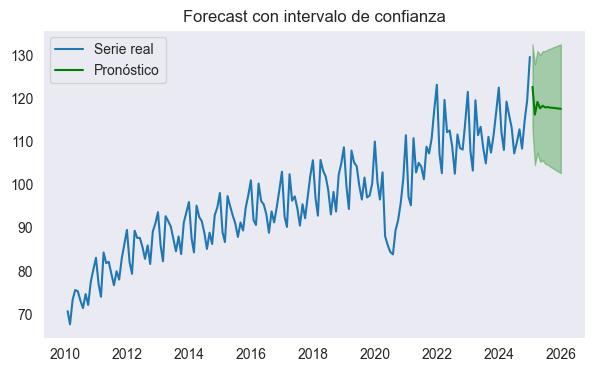

In [58]:
pred = best_model_fit.get_forecast(steps = 12)
media = pred.predicted_mean
conf_int = pred.conf_int()

# Visualizar con intervalos
plt.figure(figsize = (7, 4))
plt.plot(imacec_df, label='Serie real')
plt.plot(media, label='Pronóstico', color='green')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='green', alpha=0.3)
plt.title('Forecast con intervalo de confianza')
plt.legend()
plt.show()

Datos de Banco Central, Imacec No Minero 2025

Enero: 116,4
Febrero: 109,4
Marzo: 125,0	

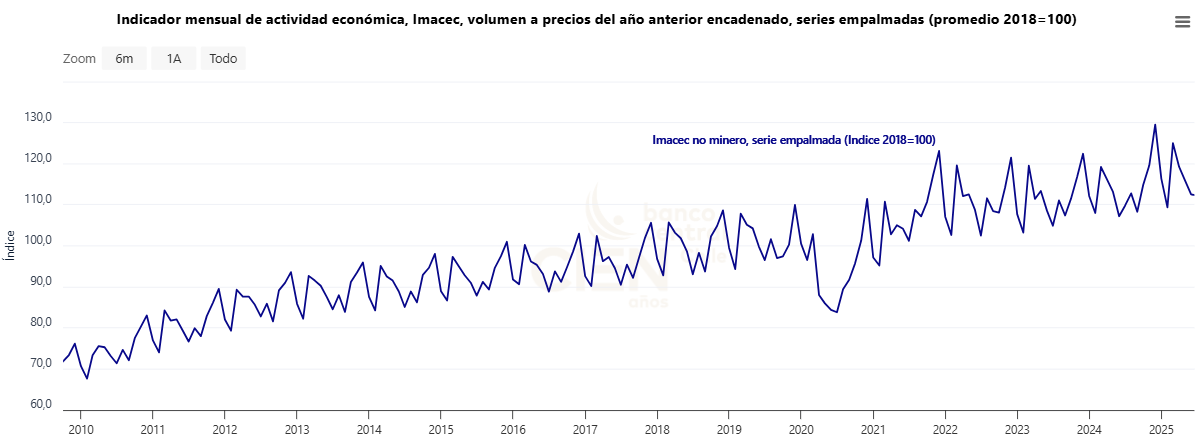

## 4. Inflación Chilena: Análisis Univariado de Series de Tiempo

La inflación es una variable central en la política monetaria chilena. En este ejercicio aplicará la metodología Box-Jenkins —vista en sesión 7— para modelar y pronosticar la inflación mensual en Chile, usando las mismas herramientas trabajadas en clases.

4.1 Datos desde la API del Banco Central
Usando bcchapi, descargue las siguientes series mensuales para el período enero 2010 – diciembre 2024:

| Variables | Código | Descripción |
|----------|--------|-------------|
| IPC | `G073.IPC.VAR.2023.M` | Variación mensual del IPC (base 2023=100) |
| TPM | `F022.TPM.TIN.D001.NO.ZD` | Tasa de Política Monetaria (%) |
| IMACEC | `F032.IMC.IND.ZZEP18.N03.Z.0.M` | IMACEC no minero (del Ejercicio 3) |

Calcule la inflación anual acumulada a 12 meses usando pct_change(12) sobre el índice de nivel del IPC (si lo descarga por separado) o bien sumando 12 variaciones mensuales consecutivas.

Grafique la inflación mensual y la anual en el mismo panel. Identifique visualmente: el efecto COVID-19 (2020) y el peak inflacionario (2021–2022).


In [ ]:
# Descarga serie IPC

ipc_df = conn.cuadro(
    series = ['G073.IPC.VAR.2023.M'], # codigo relacionado al ipc 
    nombres = ["ipc"],
    desde = "2010-01-01",
    hasta = "2024-12-31",
    frecuencia = "ME",
    observado = "mean")

In [79]:
# Variación anual deL IPC

ipc_df['ipc_12m'] = (
    (1 + ipc_df['ipc']/100)
    .rolling(12)
    .apply(np.prod, raw=True)
    - 1
) * 100

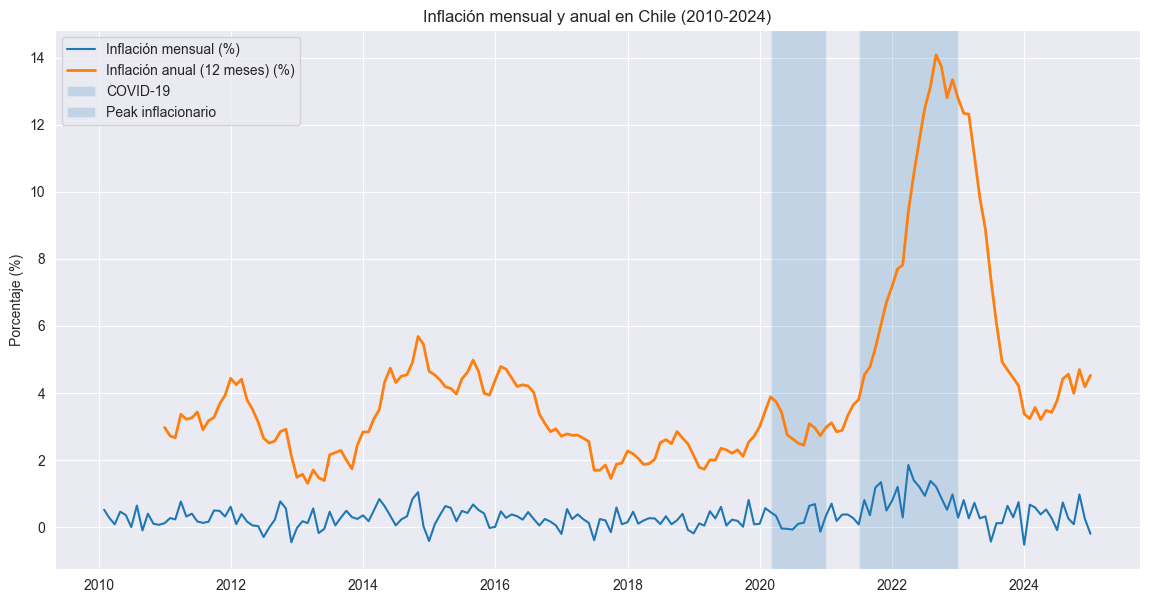

In [84]:
#Gráficos 
fig, ax = plt.subplots(figsize=(14,7))

ax.plot(
    ipc_df.index,
    ipc_df['ipc'],
    label='Inflación mensual (%)'
)

ax.plot(
    ipc_df.index,
    ipc_df['ipc_12m'],
    linewidth=2,
    label='Inflación anual (12 meses) (%)'
)

# Efecto COVID-19
ax.axvspan(
    pd.Timestamp('2020-03-01'),
    pd.Timestamp('2020-12-31'),
    alpha=0.2,
    label='COVID-19'
)

# Peak inflacionario
ax.axvspan(
    pd.Timestamp('2021-07-01'),
    pd.Timestamp('2022-12-31'),
    alpha=0.2,
    label='Peak inflacionario'
)

ax.set_title('Inflación mensual y anual en Chile (2010-2024)')
ax.set_ylabel('Porcentaje (%)')
ax.legend()
ax.grid(True)

plt.show()


## 4.2 Análisis de Estacionariedad
Trabaje con la serie de variación mensual del IPC ($\pi_t$):

1.Grafique la serie temporal.

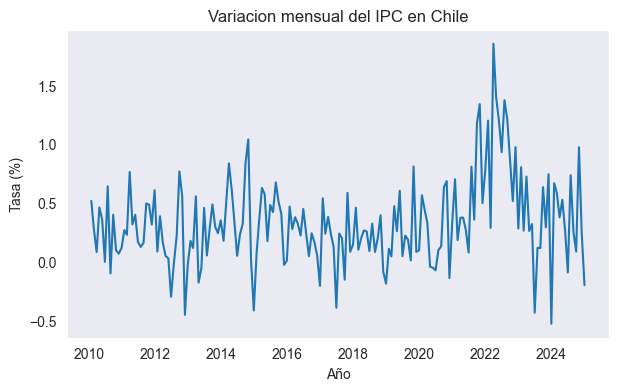

In [87]:
plt.figure(figsize = (7,4))
sns.lineplot(data = ipc_df['ipc'])
plt.xlabel('Año')
plt.ylabel('Tasa (%)')
plt.title('Variacion mensual del IPC en Chile')
plt.show()

2. Calcule y grafique la ACF y PACF con 24 rezagos. ¿Qué estructura sugieren los correlogramas?

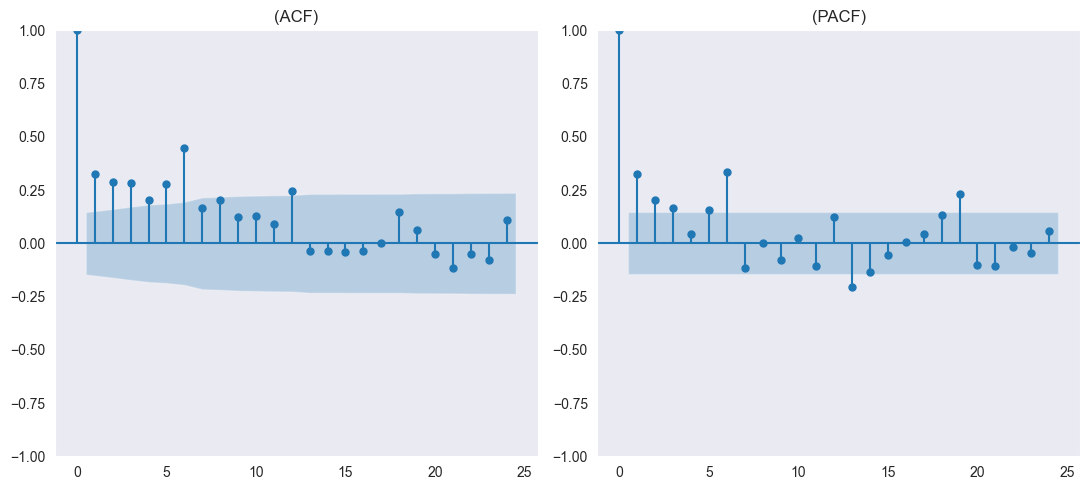

In [88]:
# Funcion que genera ACF y PACF

def plot_acf_pacf(serie, lags = None):

  # Configuro la figura a mostrar como subplots
  fig, axes = plt.subplots(1, 2, figsize=(11,5))

  # Grafico ACF
  plot_acf(serie, lags = lags, ax = axes[0], title = '(ACF)', zero = True)

  # Grafico PACF
  plot_pacf(serie, lags = lags, ax = axes[1], title = '(PACF)', zero = True)

  # Visualiza
  plt.tight_layout()
  plt.show()

# ACF y PACF Serie Imacec
plot_acf_pacf(ipc_df['ipc'], lags = 24)

Los correlogramas sugieren que los rezagos caen de forma exponencial, en la función ACF los rezagos 2 al 5 muestra un patrón de decrecimiento y en el PACF luego los rezagos 2, 3, 4 se van reduciendo o entran dentro de las bandas.

2. Aplique el test ADF. Reporte estadístico, p-value y valores críticos. ¿Es la serie estacionaria?

In [89]:
# Funcion que chequea si la serie es estacionaria
from statsmodels.tsa.stattools import adfuller

def valida_estacionariedad(serie, nivel_significancia = 0.05):

  # Aplica Test
  df_series = adfuller(serie)

  # Extrae Resultados
  estadistico_adf = df_series[0] # Estadistico del Test
  p_value = df_series[1]         # P-Valor
  lags_num = df_series[2]        # Rezagos
  o_obs = df_series[3]           # Num. Observaciones
  val_criticos = df_series[4]    # Valores Criticos

  # Determina si la serie es estacionaria
  es_estacionaria = p_value < nivel_significancia

  # Genera resumen de resultados
  resultado = {
      'Estadistico ADF': estadistico_adf,
      'P-Valor': p_value,
      'Rezagos': lags_num,
      'Num. Observaciones': o_obs,
      'valores criticos': val_criticos,
      'Es Estacionaria': es_estacionaria
  }

  # Muestra resultados
  print(f"Estadistico ADF: {estadistico_adf}")
  print(f"P-Valor: {p_value}")
  print(f"Numero de lags utilizados: {lags_num}")
  print(f"Numero de  Observaciones: {o_obs}")
  print(f"Valores Criticos: {val_criticos}")
  for clave, valor in val_criticos.items():
    print(f"  {clave}: {valor}")
  if es_estacionaria:
        print(f"La serie es estacionaria: {es_estacionaria}")
  else:
        print(f"La serie no es estacionaria: {es_estacionaria}")

  return resultado

valida_estacionariedad(ipc_df['ipc'])

Estadistico ADF: -3.1547052529107544
P-Valor: 0.022760835121932246
Numero de lags utilizados: 13
Numero de  Observaciones: 166
Valores Criticos: {'1%': np.float64(-3.4703698981001665), '5%': np.float64(-2.8791138497902193), '10%': np.float64(-2.576139407751488)}
  1%: -3.4703698981001665
  5%: -2.8791138497902193
  10%: -2.576139407751488
La serie es estacionaria: True


{'Estadistico ADF': np.float64(-3.1547052529107544),
 'P-Valor': np.float64(0.022760835121932246),
 'Rezagos': 13,
 'Num. Observaciones': 166,
 'valores criticos': {'1%': np.float64(-3.4703698981001665),
  '5%': np.float64(-2.8791138497902193),
  '10%': np.float64(-2.576139407751488)},
 'Es Estacionaria': np.True_}

Según el test Dickey Fuller (ADF) la hipótesis nula es que la serie no es estacionaria, como muetra un pvalue menor a 0.05 (0.022) entonces se rechaza la hipótesis por lo tanto la serie es estacionaria.